# Attention as Manifold Learning

This notebook explores using self-attention mechanisms for manifold learning and dimensionality reduction. We compare attention-based embeddings with traditional manifold learning methods from scikit-learn.

## Hypothesis
The attention matrix learned through self-reconstruction can be interpreted as a similarity/distance matrix that captures the intrinsic manifold structure of the data, similar to what manifold learning algorithms discover.


In [38]:
# Import required libraries
import os
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn import datasets, manifold
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device detection
def get_device():
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f"Using CUDA device: {torch.cuda.get_device_name(0)}")
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = torch.device('mps')
        print("Using MPS (Metal Performance Shaders) device")
    else:
        device = torch.device('cpu')
        print("Using CPU device")
    return device

device = get_device()


Using MPS (Metal Performance Shaders) device


## Feed-Forward MLP and Simple Self-Attention Model for Manifold Learning


In [39]:
class FeedForwardMLP(nn.Module):
    """
    Two-layer feed-forward MLP with GELU activation and dropout.
    """
    def __init__(self, input_dim, output_dim, mlp_expansion=2, dropout=0.0):
        """
        Args:
            input_dim: input feature dimension
            output_dim: output feature dimension
            mlp_expansion: expansion factor for hidden layer
            dropout: dropout rate
        """
        super().__init__()
        hidden_dim = int(input_dim * mlp_expansion)
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.Dropout(dropout)
        )
    
    def forward(self, x):
        return self.net(x)

class SimpleSelfAttention(nn.Module):
    """
    Simple self-attention model for manifold learning.
    Learns attention weights through self-reconstruction.
    Supports both linear and MLP projections for Q/K.
    """
    def __init__(self, d_model, n_hidden, use_attention_scores=False, use_mlp_projections=False):
        super().__init__()
        # Q, K projections - can use MLP for nonlinear transformations
        if use_mlp_projections:
            self.W_Q = FeedForwardMLP(d_model, n_hidden, mlp_expansion=2, dropout=0.0)
            self.W_K = FeedForwardMLP(d_model, n_hidden, mlp_expansion=2, dropout=0.0)
        else:
            self.W_Q = nn.Linear(d_model, n_hidden, bias=False)  # Query projection
            self.W_K = nn.Linear(d_model, n_hidden, bias=False)  # Key projection
        self.W_V = nn.Identity()  # Value projection (identity)
        self.d_model = d_model
        self.n_hidden = n_hidden
        self.use_attention_scores = use_attention_scores
        self.use_mlp_projections = use_mlp_projections
    
    def forward(self, x, attn_mask=None):
        """
        Args:
            x: (batch, n_points, d_model) input points
            attn_mask: optional mask tensor
        Returns:
            Dictionary with output, attn_weights, attn_scores
        """
        batch_size, n_points, d_model = x.shape
        device = x.device
        
        # Compute Q, K, V
        Q = self.W_Q(x)  # (batch, n_points, n_hidden)
        K = self.W_K(x)  # (batch, n_points, n_hidden)
        V = self.W_V(x)  # (batch, n_points, d_model)
        
        # Create diagonal mask (prevent self-attention)
        if attn_mask is None:
            attn_mask = (1 - torch.eye(n_points, device=device)).unsqueeze(0).expand(batch_size, -1, -1)
        
        # Compute attention scores
        scores = torch.bmm(Q, K.transpose(1, 2)) / (self.n_hidden**0.5)
        
        # Apply mask
        inf_masked_scores = scores.masked_fill(attn_mask == 0, float("-inf"))
        attn_weights = torch.softmax(inf_masked_scores, dim=-1)
        attn_scores = scores.masked_fill(attn_mask == 0, 0.0)
        
        # Reconstruct
        if self.use_attention_scores:
            reconstructed = torch.bmm(attn_scores, V)
        else:
            reconstructed = torch.bmm(attn_weights, V)
        
        return {
            'output': reconstructed,
            'attn_weights': attn_weights,
            'attn_scores': attn_scores
        }


## Dataset Class for Manifold Learning


In [ ]:
class ManifoldDataset(Dataset):
    """
    Simple dataset that returns the same data repeatedly.
    For manifold learning, we want to learn structure from the same point cloud.
    """
    def __init__(self, X, num_samples=1000):
        """
        Args:
            X: (N_points, D) numpy array of data points
            num_samples: number of times to repeat the data
        """
        # N_points is kind of like the sequence length
        self.X = torch.tensor(X, dtype=torch.float32) 
        self.num_samples = num_samples
        self.N_points, self.D = self.X.shape
    
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        # Always return the same data (clone to avoid in-place modifications)
        return self.X.clone()


## Training Function


In [41]:
def train_attention_manifold(model, dataset, config, device):
    """
    Train attention model for manifold learning.
    """
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'])
    
    loader = DataLoader(dataset, batch_size=config['batch_size'], shuffle=True)
    
    history = {'losses': []}
    
    for epoch in range(config['num_epochs']):
        epoch_losses = []
        for batch in loader:
            batch = batch.to(device)
            
            # Forward pass
            out = model(batch)
            recon = out['output']
            
            # Reconstruction loss
            loss = criterion(recon, batch)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_losses.append(loss.item())
        
        avg_loss = np.mean(epoch_losses)
        history['losses'].append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{config['num_epochs']}, Loss: {avg_loss:.6f}")
    
    return history


## Extract Attention-Based Embeddings

We'll use the attention matrix as a similarity matrix and convert it to distances for MDS, following the approach from the main notebook.


In [42]:
def extract_attention_embedding(model, X, device, use_attention_scores=False, n_samples=100):
    """
    Extract attention matrix and convert to 2D embedding using MDS.
    
    Args:
        model: Trained SimpleSelfAttention model
        X: (N_points, D) numpy array of data points
        device: torch device
        use_attention_scores: If True, use raw scores instead of weights
        n_samples: Number of forward passes to average over
    
    Returns:
        embedding: (N_points, 2) numpy array of 2D coordinates
        attention_matrix: (N_points, N_points) averaged attention matrix
    """
    model.eval()
    attention_matrices = []
    
    X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(0).to(device)  # Add batch dim
    
    with torch.no_grad():
        for _ in range(n_samples):
            out = model(X_tensor)
            if use_attention_scores:
                attn = out['attn_scores'].cpu().numpy()[0]  # Remove batch dim
            else:
                attn = out['attn_weights'].cpu().numpy()[0]
            attention_matrices.append(attn)
    
    # Average attention matrices
    attention_matrix = np.mean(attention_matrices, axis=0)
    
    # Convert attention (similarity) to distance matrix
    # Restore diagonal to 1.0 (self-similarity)
    np.fill_diagonal(attention_matrix, 1.0)
    
    # Symmetrize
    attention_similarity = np.clip(0.5 * (attention_matrix + attention_matrix.T), 0, 1)
    
    # Convert similarity to distance using information distance (same as main notebook)
    eps = 1e-9
    attention_distance = np.sqrt(np.maximum(0.0, -np.log(attention_similarity + eps)))
    
    # Apply MDS to get 2D embedding
    mds = manifold.MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress=False)
    embedding = mds.fit_transform(attention_distance)
    
    return embedding, attention_matrix


## Generate Datasets

We'll use the same datasets as sklearn's manifold learning examples (see [sklearn documentation](https://scikit-learn.org/stable/auto_examples/manifold/plot_compare_methods.html)).


In [46]:
# Generate S-curve dataset
n_samples = 1500
S_points, S_color = datasets.make_s_curve(n_samples, random_state=0)

print(f"S-curve dataset: {S_points.shape}")
print(f"Color range: [{S_color.min():.2f}, {S_color.max():.2f}]")


S-curve dataset: (1500, 3)
Color range: [-4.71, 4.71]


## Visualization Functions


In [47]:
# Import for 3D plotting
import mpl_toolkits.mplot3d  # noqa: F401

def plot_3d(points, color, title, ax=None):
    """Plot 3D data."""
    if ax is None:
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='3d')
    x, y, z = points.T
    ax.scatter(x, y, z, c=color, s=50, alpha=0.8, cmap=plt.cm.Spectral)
    ax.set_title(title, size=14, fontweight='bold')
    return ax

def plot_2d(points, color, title, ax=None):
    """Plot 2D embedding."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(points[:, 0], points[:, 1], c=color, s=50, alpha=0.8, cmap=plt.cm.Spectral)
    ax.set_title(title, size=14, fontweight='bold')
    ax.set_aspect('equal')
    return ax


## Train Attention Model on S-Curve


In [48]:
# Configuration
CONFIG = {
    'd_model': 3,  # S-curve is 3D
    'n_hidden': 64,
    'batch_size': 32,
    'learning_rate': 1e-3,
    'num_epochs': 100,
    'use_attention_scores': False,
    'use_mlp_projections': False  # Will test both linear and MLP
}

# Create dataset
dataset = ManifoldDataset(S_points, num_samples=1000)

print("Dataset created. We'll train both linear and MLP models in the next section.")


Dataset created. We'll train both linear and MLP models in the next section.


## Compare with Traditional Manifold Learning Methods

We'll apply various manifold learning methods from scikit-learn and compare them with our attention-based approach.


In [ ]:
# Apply various manifold learning methods
n_neighbors = 12
n_components = 2

methods = {}

# PCA (baseline linear method)
pca = PCA(n_components=n_components, random_state=42)
methods['PCA'] = pca.fit_transform(S_points)

# Locally Linear Embedding (LLE)
lle = manifold.LocallyLinearEmbedding(
    n_neighbors=n_neighbors, 
    n_components=n_components, 
    random_state=42
)
methods['LLE'] = lle.fit_transform(S_points)

# Isomap
isomap = manifold.Isomap(n_neighbors=n_neighbors, n_components=n_components)
methods['Isomap'] = isomap.fit_transform(S_points)

# MDS
mds = manifold.MDS(n_components=n_components, random_state=42, normalized_stress=False)
methods['MDS'] = mds.fit_transform(S_points)

# Spectral Embedding
spectral = manifold.SpectralEmbedding(
    n_components=n_components, 
    n_neighbors=n_neighbors, 
    random_state=42
)
methods['Spectral'] = spectral.fit_transform(S_points)

# t-SNE
tsne = manifold.TSNE(
    n_components=n_components,
    perplexity=30,
    random_state=42,
    init='random'
)
methods['t-SNE'] = tsne.fit_transform(S_points)


## Compare Linear vs MLP Projections

Let's test both linear and nonlinear (MLP) projections to see if MLP better approximates nonlinear manifold learning methods.


In [11]:
# Test both linear and MLP projections
print("="*80)
print("Testing Linear vs MLP Projections")
print("="*80)

# Linear projections
print("\n1. Training with LINEAR projections...")
CONFIG_LINEAR = CONFIG.copy()
CONFIG_LINEAR['use_mlp_projections'] = False

model_linear = SimpleSelfAttention(
    d_model=CONFIG_LINEAR['d_model'],
    n_hidden=CONFIG_LINEAR['n_hidden'],
    use_attention_scores=CONFIG_LINEAR['use_attention_scores'],
    use_mlp_projections=CONFIG_LINEAR['use_mlp_projections']
).to(device)

print(f"Linear model parameters: {sum(p.numel() for p in model_linear.parameters()):,}")
history_linear = train_attention_manifold(model_linear, dataset, CONFIG_LINEAR, device)
embedding_linear, _ = extract_attention_embedding(
    model_linear, S_points, device, 
    use_attention_scores=CONFIG_LINEAR['use_attention_scores'],
    n_samples=100
)

# MLP projections
print("\n2. Training with MLP (nonlinear) projections...")
CONFIG_MLP = CONFIG.copy()
CONFIG_MLP['use_mlp_projections'] = True

model_mlp = SimpleSelfAttention(
    d_model=CONFIG_MLP['d_model'],
    n_hidden=CONFIG_MLP['n_hidden'],
    use_attention_scores=CONFIG_MLP['use_attention_scores'],
    use_mlp_projections=CONFIG_MLP['use_mlp_projections']
).to(device)

print(f"MLP model parameters: {sum(p.numel() for p in model_mlp.parameters()):,}")
history_mlp = train_attention_manifold(model_mlp, dataset, CONFIG_MLP, device)
embedding_mlp, _ = extract_attention_embedding(
    model_mlp, S_points, device,
    use_attention_scores=CONFIG_MLP['use_attention_scores'],
    n_samples=100
)

# Add to methods dictionary
methods['Attention (Linear)'] = embedding_linear
methods['Attention (MLP)'] = embedding_mlp

print(f"\nSummary:")
print(f"  Linear model parameters: {sum(p.numel() for p in model_linear.parameters()):,}")
print(f"  MLP model parameters: {sum(p.numel() for p in model_mlp.parameters()):,}")
print(f"  Total methods for comparison: {len(methods)}")


Testing Linear vs MLP Projections

1. Training with LINEAR projections...
Linear model parameters: 384
Epoch 10/100, Loss: 0.154452
Epoch 20/100, Loss: 0.113910
Epoch 30/100, Loss: 0.105881
Epoch 40/100, Loss: 0.103251
Epoch 50/100, Loss: 0.102104
Epoch 60/100, Loss: 0.101511
Epoch 70/100, Loss: 0.101173
Epoch 80/100, Loss: 0.100971
Epoch 90/100, Loss: 0.100848
Epoch 100/100, Loss: 0.100774

2. Training with MLP (nonlinear) projections...
MLP model parameters: 944
Epoch 10/100, Loss: 0.246400
Epoch 20/100, Loss: 0.113719
Epoch 30/100, Loss: 0.023725
Epoch 40/100, Loss: 0.020308
Epoch 50/100, Loss: 0.018705
Epoch 60/100, Loss: 0.017262
Epoch 70/100, Loss: 0.016007
Epoch 80/100, Loss: 0.014847
Epoch 90/100, Loss: 0.013894
Epoch 100/100, Loss: 0.013013

Summary:
  Linear model parameters: 384
  MLP model parameters: 944
  Total methods for comparison: 8


## Visualize Comparisons


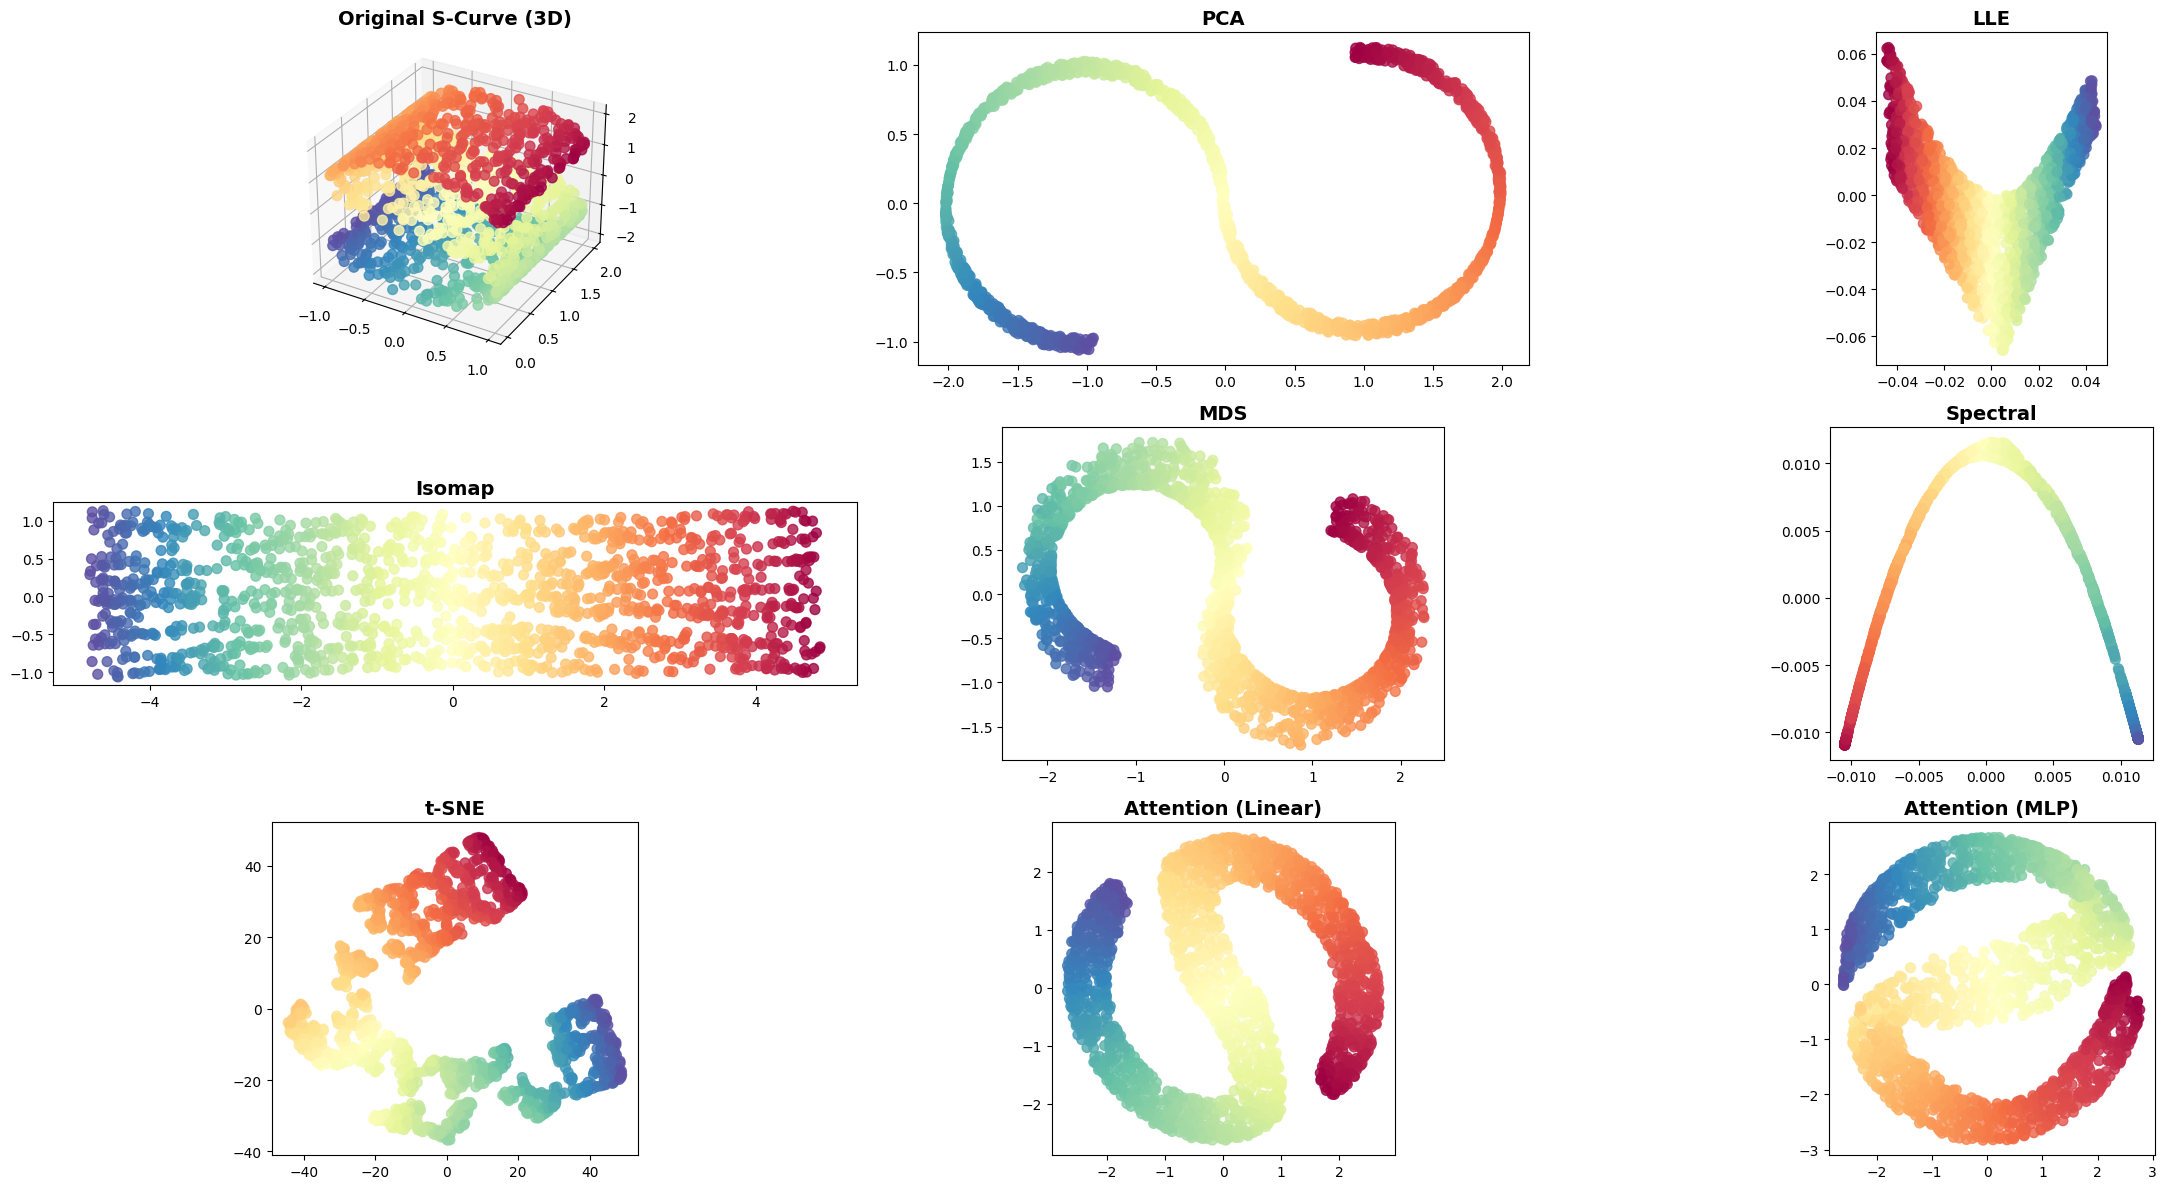

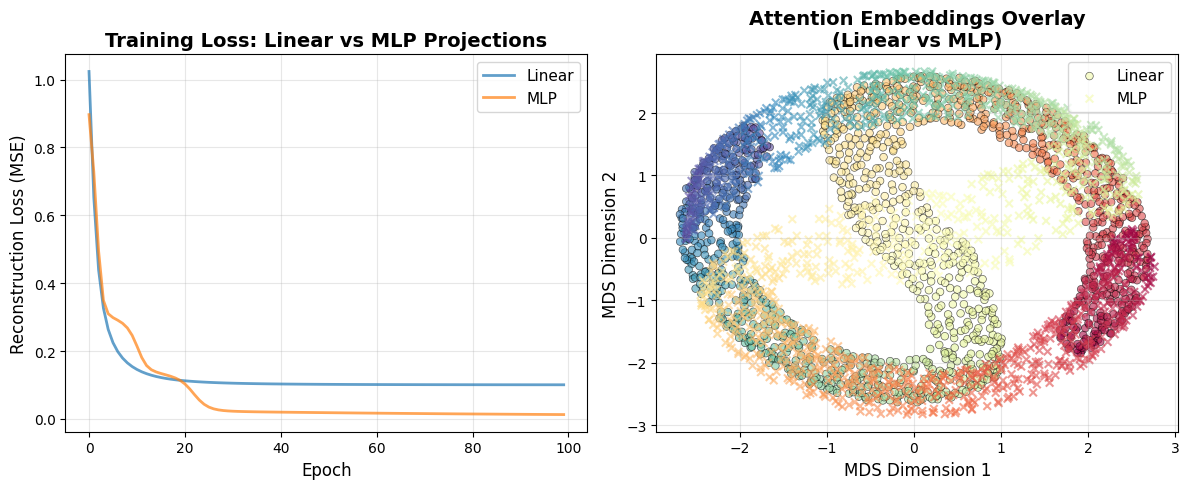

In [ ]:
# Create comparison plot (including both linear and MLP attention on separate subplots)
fig = plt.figure(figsize=(24, 12))

# Plot original 3D data
ax = fig.add_subplot(3, 3, 1, projection='3d')
plot_3d(S_points, S_color, 'Original S-Curve (3D)', ax)

# Plot sklearn methods
sklearn_methods = ['PCA', 'LLE', 'Isomap', 'MDS', 'Spectral', 't-SNE']
for idx, method_name in enumerate(sklearn_methods, start=2):
    if method_name in methods:
        ax = fig.add_subplot(3, 3, idx)
        plot_2d(methods[method_name], S_color, method_name, ax)

# Plot attention methods on separate subplots
ax = fig.add_subplot(3, 3, 8)
plot_2d(methods['Attention (Linear)'], S_color, 'Attention (Linear)', ax)

ax = fig.add_subplot(3, 3, 9)
plot_2d(methods['Attention (MLP)'], S_color, 'Attention (MLP)', ax)

plt.tight_layout()
plt.show()

# Plot training curves comparison
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_linear['losses'], label='Linear', alpha=0.7, linewidth=2)
plt.plot(history_mlp['losses'], label='MLP', alpha=0.7, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Reconstruction Loss (MSE)', fontsize=12)
plt.title('Training Loss: Linear vs MLP Projections', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Compare final embeddings side-by-side (separate subplots)
plt.subplot(1, 2, 2)
plt.scatter(embedding_linear[:, 0], embedding_linear[:, 1], c=S_color, s=30, alpha=0.6, cmap=plt.cm.Spectral, edgecolors='black', linewidths=0.5)
plt.xlabel('MDS Dimension 1', fontsize=12)
plt.ylabel('MDS Dimension 2', fontsize=12)
plt.title('Attention (Linear) Embedding', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(embedding_mlp[:, 0], embedding_mlp[:, 1], c=S_color, s=30, alpha=0.6, cmap=plt.cm.Spectral, edgecolors='black', linewidths=0.5)
plt.xlabel('MDS Dimension 1', fontsize=12)
plt.ylabel('MDS Dimension 2', fontsize=12)
plt.title('Attention (MLP) Embedding', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Test on Swiss Roll Dataset

Let's test on another classic manifold learning dataset.


Swiss Roll dataset: (1500, 3)

Swiss Roll: Testing Linear vs MLP Projections

Training Swiss Roll with LINEAR projections...
Epoch 10/100, Loss: 10.326614
Epoch 20/100, Loss: 10.311214
Epoch 30/100, Loss: 10.311214
Epoch 40/100, Loss: 10.311214
Epoch 50/100, Loss: 10.311214
Epoch 60/100, Loss: 10.311214
Epoch 70/100, Loss: 10.311214
Epoch 80/100, Loss: 10.311214
Epoch 90/100, Loss: 10.316593
Epoch 100/100, Loss: 10.311216

Training Swiss Roll with MLP projections...
Epoch 10/100, Loss: 4.242830
Epoch 20/100, Loss: 1.301925
Epoch 30/100, Loss: 0.841263
Epoch 40/100, Loss: 0.696680
Epoch 50/100, Loss: 0.616343
Epoch 60/100, Loss: 0.547957
Epoch 70/100, Loss: 0.495044
Epoch 80/100, Loss: 0.460463
Epoch 90/100, Loss: 0.436857
Epoch 100/100, Loss: 0.421267


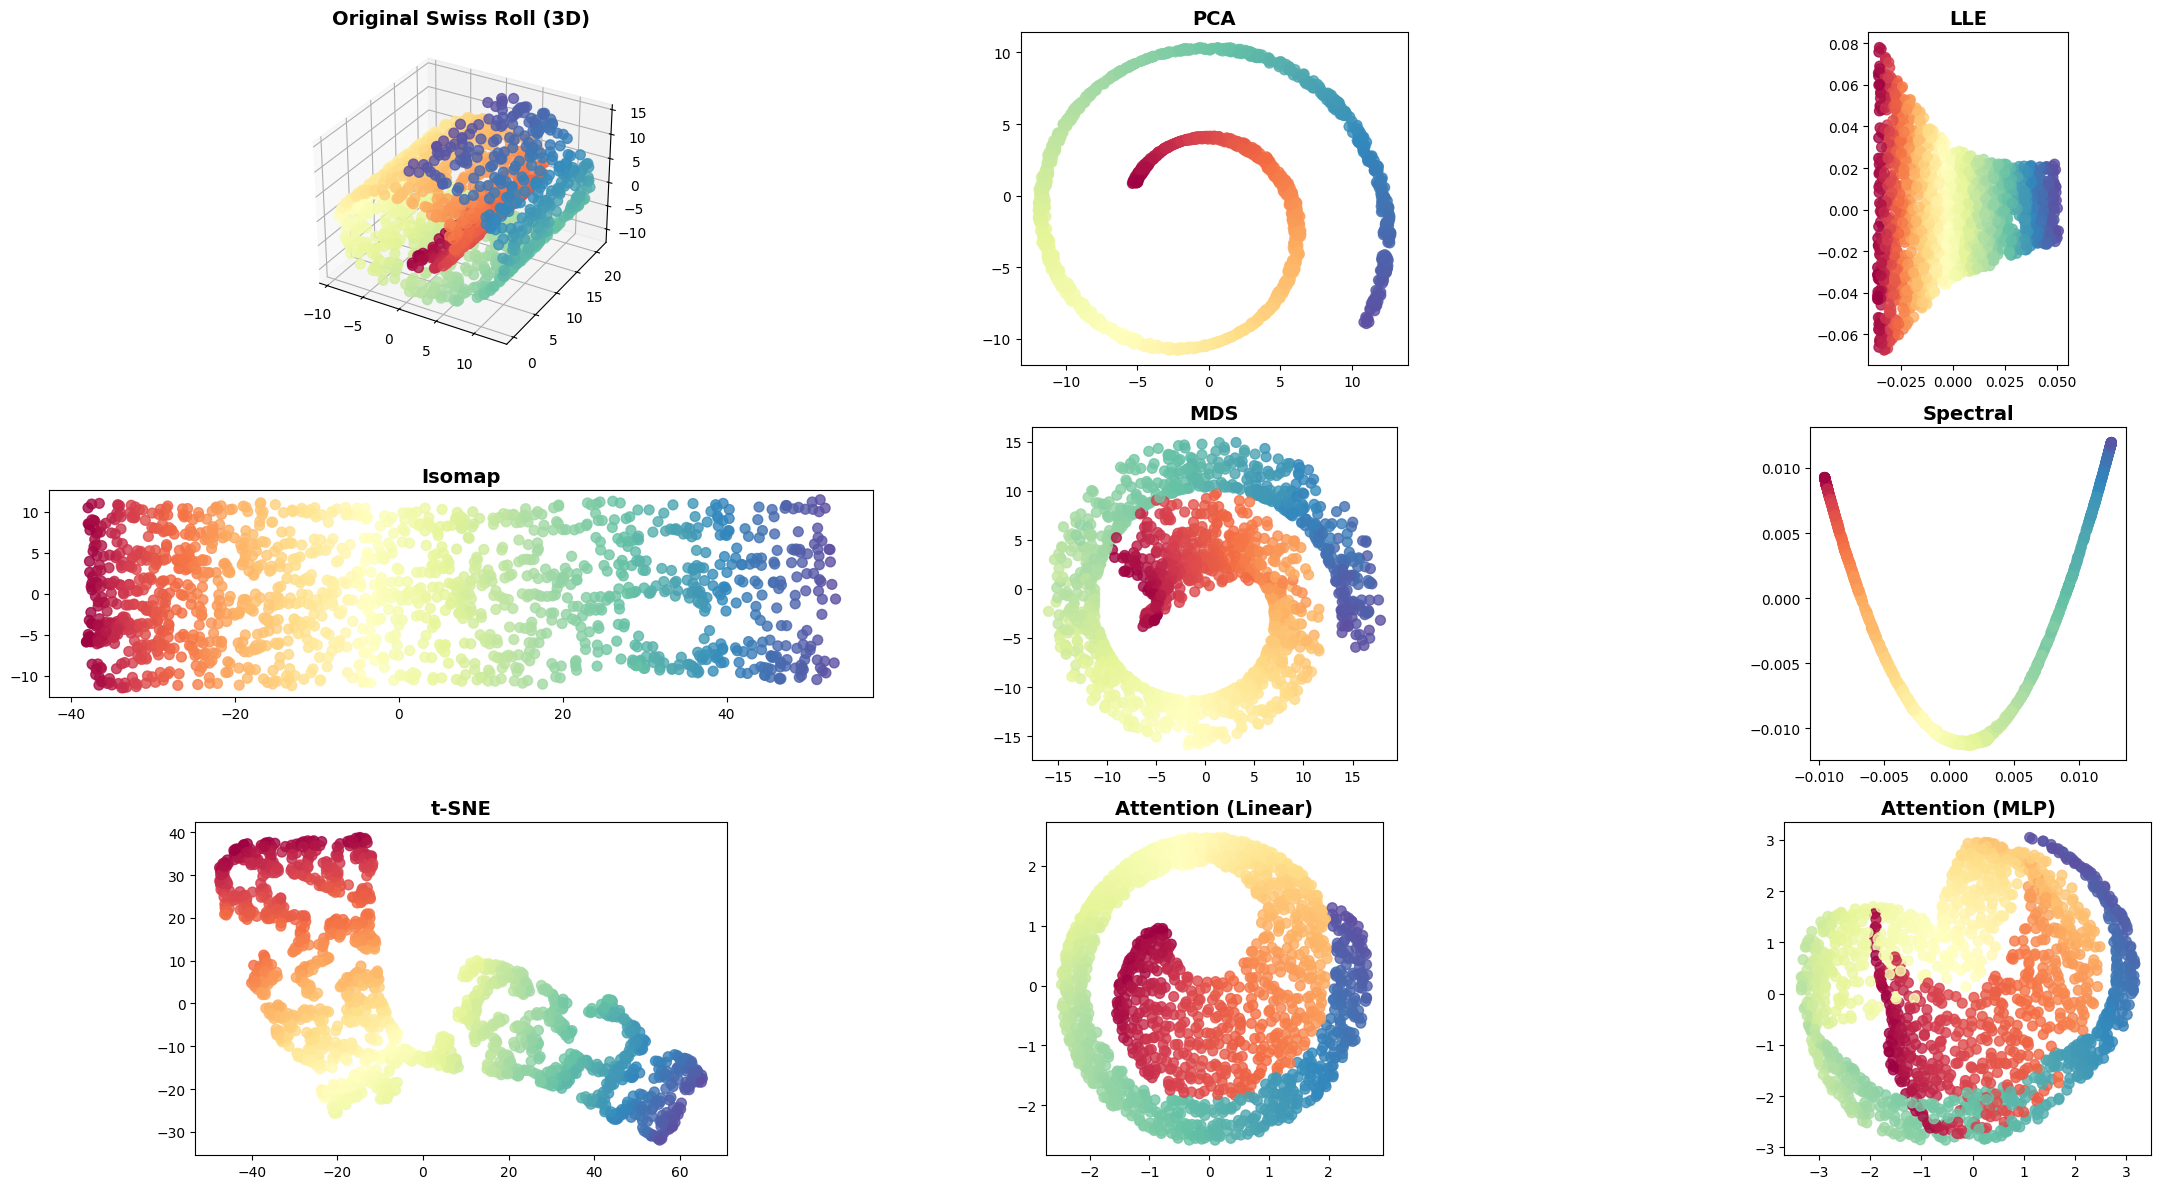

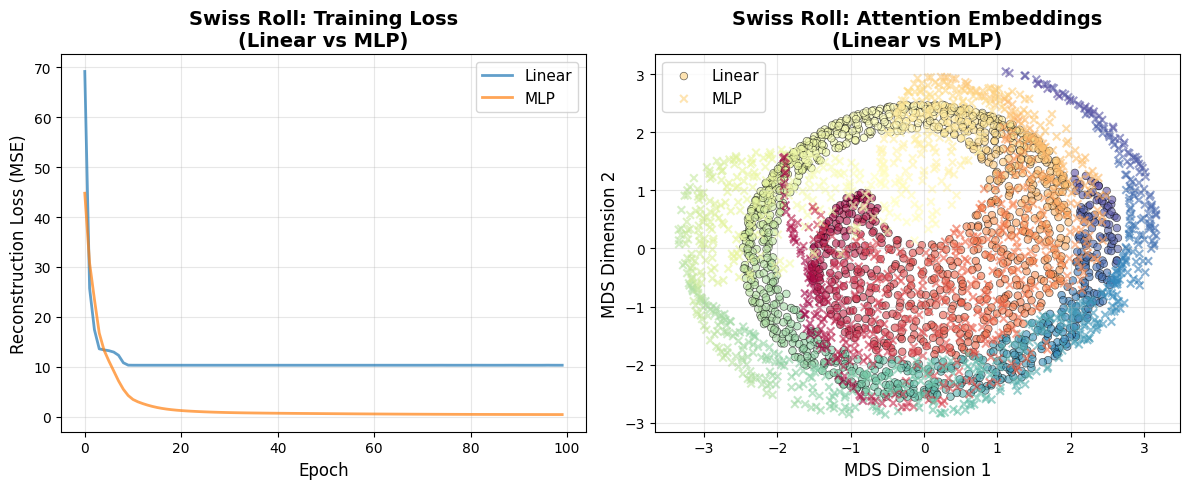

In [ ]:
# Generate Swiss Roll dataset
swiss_points, swiss_color = datasets.make_swiss_roll(n_samples=1500, random_state=42)

print(f"Swiss Roll dataset: {swiss_points.shape}")

# Train on Swiss Roll with both linear and MLP
print("\n" + "="*80)
print("Swiss Roll: Testing Linear vs MLP Projections")
print("="*80)

swiss_dataset = ManifoldDataset(swiss_points, num_samples=1000)

# Linear
swiss_model_linear = SimpleSelfAttention(
    d_model=3,
    n_hidden=64,
    use_attention_scores=CONFIG['use_attention_scores'],
    use_mlp_projections=False
).to(device)

print("\nTraining Swiss Roll with LINEAR projections...")
swiss_history_linear = train_attention_manifold(swiss_model_linear, swiss_dataset, CONFIG, device)
swiss_embedding_linear, _ = extract_attention_embedding(
    swiss_model_linear, swiss_points, device, n_samples=100
)

# MLP
swiss_model_mlp = SimpleSelfAttention(
    d_model=3,
    n_hidden=64,
    use_attention_scores=CONFIG['use_attention_scores'],
    use_mlp_projections=True
).to(device)

print("\nTraining Swiss Roll with MLP projections...")
swiss_history_mlp = train_attention_manifold(swiss_model_mlp, swiss_dataset, CONFIG, device)
swiss_embedding_mlp, _ = extract_attention_embedding(
    swiss_model_mlp, swiss_points, device, n_samples=100
)

# Apply other methods
swiss_methods = {}
swiss_methods['PCA'] = PCA(n_components=2, random_state=42).fit_transform(swiss_points)
swiss_methods['LLE'] = manifold.LocallyLinearEmbedding(n_neighbors=12, n_components=2, random_state=42).fit_transform(swiss_points)
swiss_methods['Isomap'] = manifold.Isomap(n_neighbors=12, n_components=2).fit_transform(swiss_points)
swiss_methods['MDS'] = manifold.MDS(n_components=2, random_state=42, normalized_stress=False).fit_transform(swiss_points)
swiss_methods['Spectral'] = manifold.SpectralEmbedding(n_components=2, n_neighbors=12, random_state=42).fit_transform(swiss_points)
swiss_methods['t-SNE'] = manifold.TSNE(n_components=2, perplexity=30, random_state=42, init='random').fit_transform(swiss_points)
swiss_methods['Attention (Linear)'] = swiss_embedding_linear
swiss_methods['Attention (MLP)'] = swiss_embedding_mlp

# Visualize (with attention methods on separate subplots)
fig = plt.figure(figsize=(24, 12))
ax = fig.add_subplot(3, 3, 1, projection='3d')
plot_3d(swiss_points, swiss_color, 'Original Swiss Roll (3D)', ax)

# Plot sklearn methods
swiss_sklearn_methods = ['PCA', 'LLE', 'Isomap', 'MDS', 'Spectral', 't-SNE']
for idx, method_name in enumerate(swiss_sklearn_methods, start=2):
    if method_name in swiss_methods:
        ax = fig.add_subplot(3, 3, idx)
        plot_2d(swiss_methods[method_name], swiss_color, method_name, ax)

# Plot attention methods on separate subplots
ax = fig.add_subplot(3, 3, 8)
plot_2d(swiss_methods['Attention (Linear)'], swiss_color, 'Attention (Linear)', ax)

ax = fig.add_subplot(3, 3, 9)
plot_2d(swiss_methods['Attention (MLP)'], swiss_color, 'Attention (MLP)', ax)

plt.tight_layout()
plt.show()

# Plot training curves for Swiss Roll
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(swiss_history_linear['losses'], label='Linear', alpha=0.7, linewidth=2)
plt.plot(swiss_history_mlp['losses'], label='MLP', alpha=0.7, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Reconstruction Loss (MSE)', fontsize=12)
plt.title('Swiss Roll: Training Loss\n(Linear vs MLP)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Compare embeddings (separate subplots)
plt.subplot(1, 2, 2)
plt.scatter(swiss_embedding_linear[:, 0], swiss_embedding_linear[:, 1], c=swiss_color, s=30, alpha=0.6, cmap=plt.cm.Spectral, edgecolors='black', linewidths=0.5)
plt.xlabel('MDS Dimension 1', fontsize=12)
plt.ylabel('MDS Dimension 2', fontsize=12)
plt.title('Swiss Roll: Attention (Linear)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(swiss_embedding_mlp[:, 0], swiss_embedding_mlp[:, 1], c=swiss_color, s=30, alpha=0.6, cmap=plt.cm.Spectral, edgecolors='black', linewidths=0.5)
plt.xlabel('MDS Dimension 1', fontsize=12)
plt.ylabel('MDS Dimension 2', fontsize=12)
plt.title('Swiss Roll: Attention (MLP)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Test on MNIST/Digits Dataset (High-Dimensional)

Let's test on a higher-dimensional dataset: the digits dataset (64-dimensional, 8x8 pixel images). This is a more realistic test case for manifold learning, as referenced in the [sklearn documentation](https://scikit-learn.org/stable/auto_examples/manifold/plot_lle_digits.html).


In [52]:
# Load digits dataset (64-dimensional)
from sklearn.datasets import load_digits

digits = load_digits(n_class=6)  # Use 6 classes for faster computation
digits_points = digits.data
digits_labels = digits.target

print(f"Digits dataset: {digits_points.shape}")
print(f"Number of classes: {len(np.unique(digits_labels))}")
print(f"Classes: {np.unique(digits_labels)}")

# Normalize to [0, 1] for better training
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
digits_points_scaled = scaler.fit_transform(digits_points)

print(f"\nScaled data range: [{digits_points_scaled.min():.3f}, {digits_points_scaled.max():.3f}]")


Digits dataset: (1083, 64)
Number of classes: 6
Classes: [0 1 2 3 4 5]

Scaled data range: [0.000, 1.000]


In [53]:
# Train on Digits with both linear and MLP
print("\n" + "="*80)
print("Digits Dataset: Testing Linear vs MLP Projections")
print("="*80)

# Configuration for digits (64-dimensional)
CONFIG_DIGITS = {
    'd_model': 64,  # Digits are 64-dimensional
    'n_hidden': 128,  # Larger hidden dim for higher-dimensional data
    'batch_size': 32,
    'learning_rate': 1e-3,
    'num_epochs': 150,  # More epochs for higher-dimensional data
    'use_attention_scores': False,
    'use_mlp_projections': False
}

digits_dataset = ManifoldDataset(digits_points_scaled, num_samples=1000)

# Linear
digits_model_linear = SimpleSelfAttention(
    d_model=CONFIG_DIGITS['d_model'],
    n_hidden=CONFIG_DIGITS['n_hidden'],
    use_attention_scores=CONFIG_DIGITS['use_attention_scores'],
    use_mlp_projections=False
).to(device)

print(f"\nLinear model parameters: {sum(p.numel() for p in digits_model_linear.parameters()):,}")
print("\nTraining Digits with LINEAR projections...")
digits_history_linear = train_attention_manifold(digits_model_linear, digits_dataset, CONFIG_DIGITS, device)
digits_embedding_linear, _ = extract_attention_embedding(
    digits_model_linear, digits_points_scaled, device, n_samples=100
)

# MLP
digits_model_mlp = SimpleSelfAttention(
    d_model=CONFIG_DIGITS['d_model'],
    n_hidden=CONFIG_DIGITS['n_hidden'],
    use_attention_scores=CONFIG_DIGITS['use_attention_scores'],
    use_mlp_projections=True
).to(device)

print(f"\nMLP model parameters: {sum(p.numel() for p in digits_model_mlp.parameters()):,}")
print("\nTraining Digits with MLP projections...")
digits_history_mlp = train_attention_manifold(digits_model_mlp, digits_dataset, CONFIG_DIGITS, device)
digits_embedding_mlp, _ = extract_attention_embedding(
    digits_model_mlp, digits_points_scaled, device, n_samples=100
)



Digits Dataset: Testing Linear vs MLP Projections

Linear model parameters: 16,384

Training Digits with LINEAR projections...
Epoch 10/150, Loss: 0.023323
Epoch 20/150, Loss: 0.016409
Epoch 30/150, Loss: 0.013863
Epoch 40/150, Loss: 0.012643
Epoch 50/150, Loss: 0.011880
Epoch 60/150, Loss: 0.011390
Epoch 70/150, Loss: 0.011047
Epoch 80/150, Loss: 0.010780
Epoch 90/150, Loss: 0.010561
Epoch 100/150, Loss: 0.010370
Epoch 110/150, Loss: 0.010199
Epoch 120/150, Loss: 0.010051
Epoch 130/150, Loss: 0.009920
Epoch 140/150, Loss: 0.009801
Epoch 150/150, Loss: 0.009694

MLP model parameters: 49,664

Training Digits with MLP projections...
Epoch 10/150, Loss: 0.016318
Epoch 20/150, Loss: 0.011488
Epoch 30/150, Loss: 0.010703
Epoch 40/150, Loss: 0.010308
Epoch 50/150, Loss: 0.009993
Epoch 60/150, Loss: 0.009752
Epoch 70/150, Loss: 0.009555
Epoch 80/150, Loss: 0.009417
Epoch 90/150, Loss: 0.009296
Epoch 100/150, Loss: 0.009212
Epoch 110/150, Loss: 0.009116
Epoch 120/150, Loss: 0.009041
Epoch 130

In [54]:
# Apply sklearn methods to digits
print("\nApplying sklearn manifold learning methods to digits...")
digits_methods = {}

# PCA
digits_methods['PCA'] = PCA(n_components=2, random_state=42).fit_transform(digits_points_scaled)

# LLE
digits_methods['LLE'] = manifold.LocallyLinearEmbedding(
    n_neighbors=30, n_components=2, random_state=42
).fit_transform(digits_points_scaled)

# Isomap
digits_methods['Isomap'] = manifold.Isomap(n_neighbors=30, n_components=2).fit_transform(digits_points_scaled)

# MDS
digits_methods['MDS'] = manifold.MDS(n_components=2, random_state=42, normalized_stress=False).fit_transform(digits_points_scaled)

# Spectral Embedding
digits_methods['Spectral'] = manifold.SpectralEmbedding(
    n_components=2, n_neighbors=30, random_state=42
).fit_transform(digits_points_scaled)

# t-SNE (may take longer)
print("Computing t-SNE (this may take a while)...")
digits_methods['t-SNE'] = manifold.TSNE(
    n_components=2, perplexity=30, random_state=42, init='random'
).fit_transform(digits_points_scaled)

# Add attention methods
digits_methods['Attention (Linear)'] = digits_embedding_linear
digits_methods['Attention (MLP)'] = digits_embedding_mlp

print(f"\nApplied {len(digits_methods)} methods to digits dataset")



Applying sklearn manifold learning methods to digits...
Computing t-SNE (this may take a while)...

Applied 8 methods to digits dataset


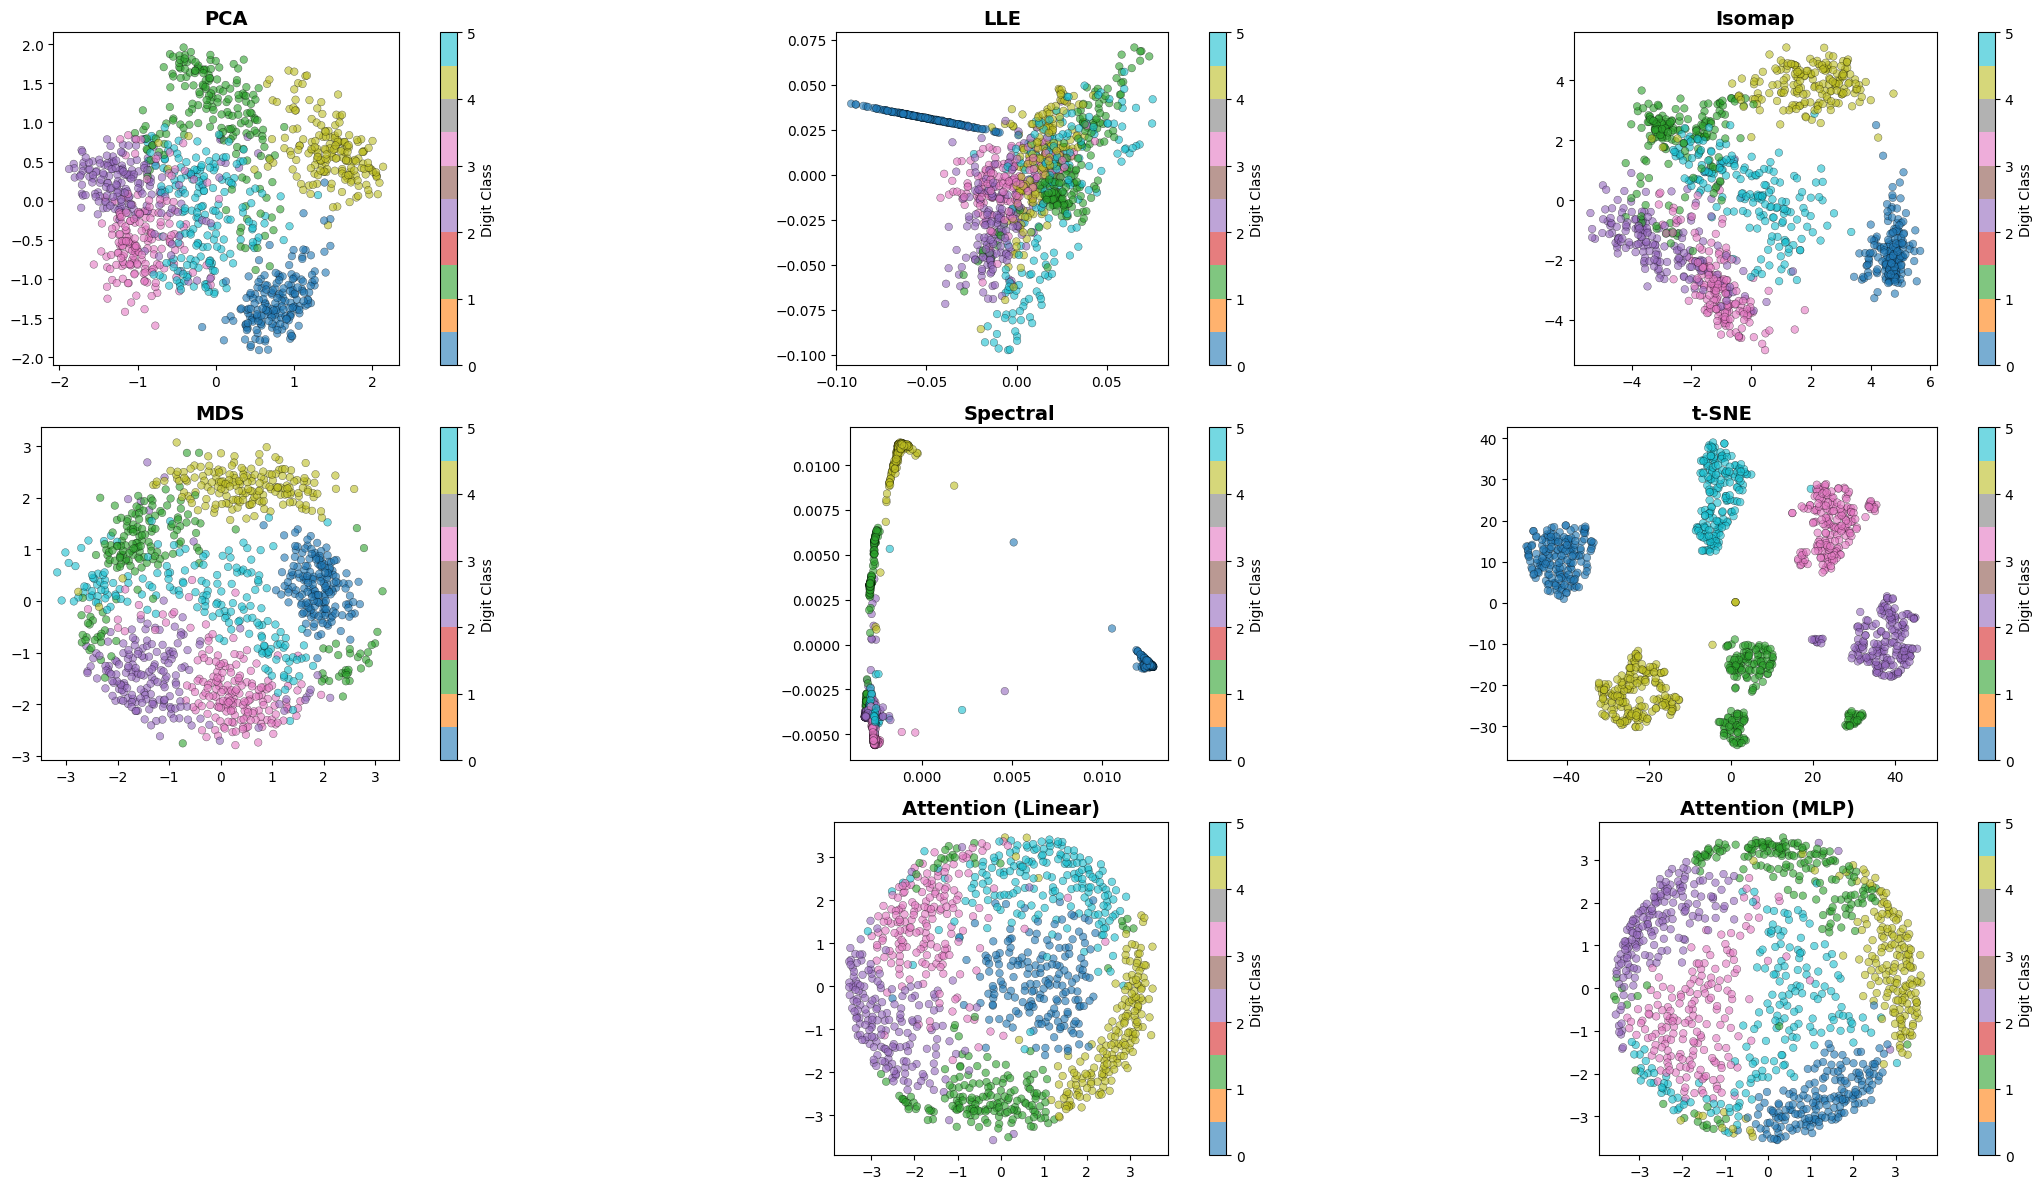

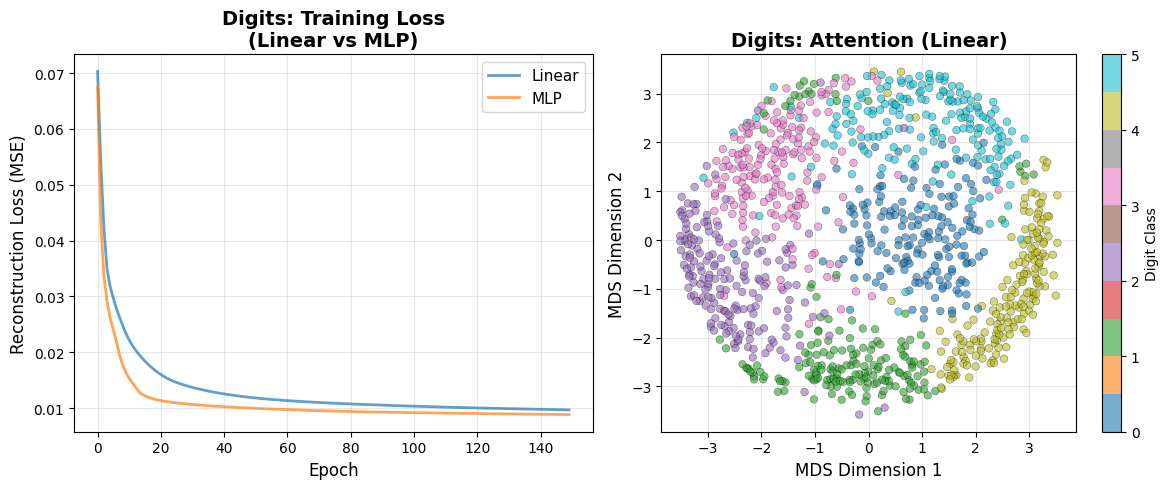

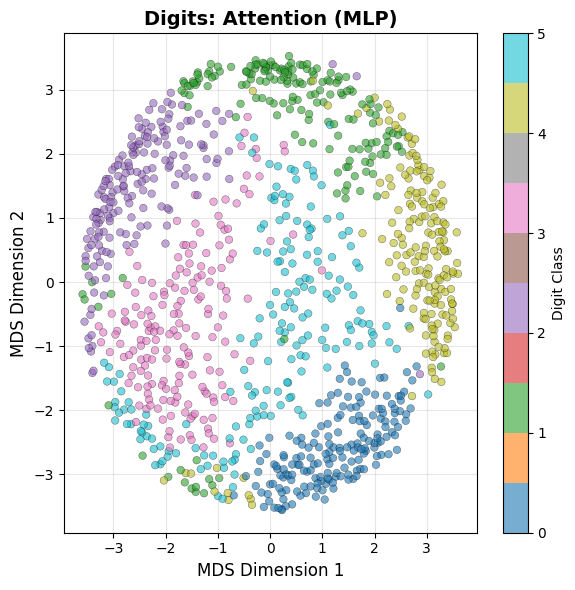

In [55]:
# Visualize digits embeddings (with attention on separate subplots)
fig = plt.figure(figsize=(24, 12))

# Plot sklearn methods
digits_sklearn_methods = ['PCA', 'LLE', 'Isomap', 'MDS', 'Spectral', 't-SNE']
for idx, method_name in enumerate(digits_sklearn_methods, start=1):
    if method_name in digits_methods:
        ax = fig.add_subplot(3, 3, idx)
        # Use digit labels for coloring
        scatter = ax.scatter(
            digits_methods[method_name][:, 0], 
            digits_methods[method_name][:, 1], 
            c=digits_labels, s=30, alpha=0.6, cmap=plt.cm.tab10, edgecolors='black', linewidths=0.3
        )
        ax.set_title(method_name, size=14, fontweight='bold')
        ax.set_aspect('equal')
        plt.colorbar(scatter, ax=ax, label='Digit Class')

# Plot attention methods on separate subplots
ax = fig.add_subplot(3, 3, 8)
scatter = ax.scatter(
    digits_methods['Attention (Linear)'][:, 0], 
    digits_methods['Attention (Linear)'][:, 1], 
    c=digits_labels, s=30, alpha=0.6, cmap=plt.cm.tab10, edgecolors='black', linewidths=0.3
)
ax.set_title('Attention (Linear)', size=14, fontweight='bold')
ax.set_aspect('equal')
plt.colorbar(scatter, ax=ax, label='Digit Class')

ax = fig.add_subplot(3, 3, 9)
scatter = ax.scatter(
    digits_methods['Attention (MLP)'][:, 0], 
    digits_methods['Attention (MLP)'][:, 1], 
    c=digits_labels, s=30, alpha=0.6, cmap=plt.cm.tab10, edgecolors='black', linewidths=0.3
)
ax.set_title('Attention (MLP)', size=14, fontweight='bold')
ax.set_aspect('equal')
plt.colorbar(scatter, ax=ax, label='Digit Class')

plt.tight_layout()
plt.show()

# Plot training curves for digits
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(digits_history_linear['losses'], label='Linear', alpha=0.7, linewidth=2)
plt.plot(digits_history_mlp['losses'], label='MLP', alpha=0.7, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Reconstruction Loss (MSE)', fontsize=12)
plt.title('Digits: Training Loss\n(Linear vs MLP)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Compare embeddings (separate subplots)
plt.subplot(1, 2, 2)
plt.scatter(
    digits_embedding_linear[:, 0], digits_embedding_linear[:, 1], 
    c=digits_labels, s=30, alpha=0.6, cmap=plt.cm.tab10, edgecolors='black', linewidths=0.3
)
plt.xlabel('MDS Dimension 1', fontsize=12)
plt.ylabel('MDS Dimension 2', fontsize=12)
plt.title('Digits: Attention (Linear)', fontsize=14, fontweight='bold')
plt.colorbar(label='Digit Class')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(
    digits_embedding_mlp[:, 0], digits_embedding_mlp[:, 1], 
    c=digits_labels, s=30, alpha=0.6, cmap=plt.cm.tab10, edgecolors='black', linewidths=0.3
)
plt.xlabel('MDS Dimension 1', fontsize=12)
plt.ylabel('MDS Dimension 2', fontsize=12)
plt.title('Digits: Attention (MLP)', fontsize=14, fontweight='bold')
plt.colorbar(label='Digit Class')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Analysis: Are Results Too Good to Be True?

Let's verify that our attention-based method is actually learning meaningful structure by:
1. Checking reconstruction quality
2. Comparing attention matrices between linear and MLP
3. Analyzing whether the embeddings preserve class structure


In [56]:
# Verify reconstruction quality and attention patterns
print("="*80)
print("Verification Analysis")
print("="*80)

# Check reconstruction error on test data
def check_reconstruction_quality(model, X, device, name):
    """Check how well the model reconstructs the input."""
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(0).to(device)
    
    with torch.no_grad():
        out = model(X_tensor)
        recon = out['output'].cpu().numpy()[0]
        mse = np.mean((X - recon) ** 2)
        mae = np.mean(np.abs(X - recon))
    
    print(f"\n{name} Reconstruction Quality:")
    print(f"  MSE: {mse:.6f}")
    print(f"  MAE: {mae:.6f}")
    print(f"  Relative Error: {mae / (np.abs(X).mean() + 1e-9):.4%}")
    return mse, mae

# Check for S-curve
print("\n--- S-Curve Dataset ---")
mse_linear, mae_linear = check_reconstruction_quality(model_linear, S_points, device, "Linear")
mse_mlp, mae_mlp = check_reconstruction_quality(model_mlp, S_points, device, "MLP")

# Check for digits
print("\n--- Digits Dataset ---")
mse_digits_linear, mae_digits_linear = check_reconstruction_quality(
    digits_model_linear, digits_points_scaled, device, "Linear"
)
mse_digits_mlp, mae_digits_mlp = check_reconstruction_quality(
    digits_model_mlp, digits_points_scaled, device, "MLP"
)

# Check if embeddings preserve class structure (for digits)
from sklearn.metrics import silhouette_score

print("\n--- Class Separation Analysis (Digits) ---")
for method_name, embedding in digits_methods.items():
    if embedding.shape[0] == len(digits_labels):
        sil_score = silhouette_score(embedding, digits_labels)
        print(f"{method_name:20s}: Silhouette Score = {sil_score:.4f}")


Verification Analysis

--- S-Curve Dataset ---

Linear Reconstruction Quality:
  MSE: 0.100771
  MAE: 0.224354
  Relative Error: 23.3077%

MLP Reconstruction Quality:
  MSE: 0.012977
  MAE: 0.091757
  Relative Error: 9.5324%

--- Digits Dataset ---

Linear Reconstruction Quality:
  MSE: 0.009689
  MAE: 0.058517
  Relative Error: 19.0882%

MLP Reconstruction Quality:
  MSE: 0.008851
  MAE: 0.055375
  Relative Error: 18.0633%

--- Class Separation Analysis (Digits) ---
PCA                 : Silhouette Score = 0.3267
LLE                 : Silhouette Score = 0.0840
Isomap              : Silhouette Score = 0.4091
MDS                 : Silhouette Score = 0.2726
Spectral            : Silhouette Score = 0.5027
t-SNE               : Silhouette Score = 0.6469
Attention (Linear)  : Silhouette Score = 0.2785
Attention (MLP)     : Silhouette Score = 0.2642
